# Returns, Volatility, and Geometric Brownian Motion

## Load data

In [106]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from typing import List, Dict
from collections import defaultdict

In [107]:
ticker = '^GSPC'
spx = yf.download(ticker, start='2025-01-01', end='2026-01-01')

spx.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2025-01-02,5868.549805,5935.089844,5829.529785,5903.259766,3621680000
2025-01-03,5942.470215,5949.339844,5888.660156,5891.069824,3667340000
2025-01-06,5975.379883,6021.040039,5960.009766,5982.810059,4940120000
2025-01-07,5909.029785,6000.680176,5890.680176,5993.259766,4517330000
2025-01-08,5918.250000,5927.890137,5874.779785,5910.660156,4441740000


## Compute simple and log returns

Simple return: $R_t = \frac{S_t - S_{t-1}}{S_{t-1}}$

Log return: $r_t = ln(\frac{S_t}{S_{t-1}})$

Relationship: $r_t = ln(R_t + 1) \approx R_t$ for small returns

Log returns are additive through time, simplifying multi-period calculations:

&nbsp;&nbsp;$r_{0,T} = ln(\frac{S_T}{S_0}) = \sum_{t=1}^T ln(\frac{S_t}{S_{t-1}}) = \sum_{t=1}^T r_t$

&nbsp;&nbsp;$R_{0,T} = \prod_{t=1}^T (1+R_t) - 1$


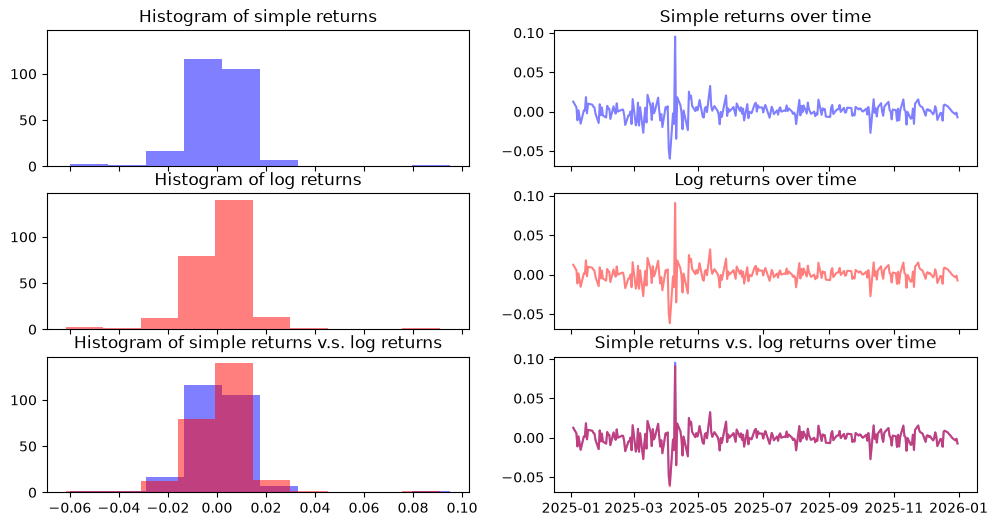

In [108]:
# simple returns
close = spx['Close'].values
lag = 1
lagged_close = close[:-lag]
current_close = close[lag:]
simple_returns = (current_close - lagged_close) / lagged_close

# log returns
log_returns = np.log(current_close / lagged_close)

# days
price_days = spx.index
return_days = spx.index[lag:]

fig, ax = plt.subplots(figsize=(12,6), ncols=2, nrows=3, sharex='col', sharey='col')

# plot histograms
ax[0][0].hist(simple_returns, alpha=0.5, color='b')
ax[0][0].set_title("Histogram of simple returns")

ax[1][0].hist(log_returns, alpha=0.5, color='r')
ax[1][0].set_title("Histogram of log returns")

# plot time series
ax[0][1].plot(return_days, simple_returns, alpha=0.5, color='b')
ax[0][1].set_title("Simple returns over time")

ax[1][1].plot(return_days, log_returns, alpha=0.5, color='r')
ax[1][1].set_title("Log returns over time")

# plot simple v.s. log returns
ax[2][0].hist(simple_returns, alpha=0.5, color='b')
ax[2][0].hist(log_returns, alpha=0.5, color='r')
ax[2][0].set_title("Histogram of simple returns v.s. log returns")

ax[2][1].plot(return_days, simple_returns, alpha=0.5, color='b')
ax[2][1].plot(return_days, log_returns, alpha=0.5, color='r')
ax[2][1].set_title("Simple returns v.s. log returns over time")

plt.show();


## Simulate Geometric Brownian Motion

1. Brownian Motion (Wiener Process) $W_t$:

* Starts at origin: $W_0 = 0$
* Independent increments: $\Delta W_{t_k} = W_{t_k} - W_{t_{k-1}}$ are independent for all $t_k$
* Stationary and normal increments: $\forall s < t, W_t - W_s \sim \mathcal{N}(0, t-s)$
* Continuous paths: With probability 1, the function $t \rightarrow W_t$ is continuous

2. Ito's lemma: 

$f(S_t + d S_t) = f(S_t) + f'(S_t) d S_t + \frac{1}{2} f''(S_t) (d S_t)^2$

$=> d f(S_t) = f(S_t + d S_t) - f(S_t) = f'(S_t) d S_t + \frac{1}{2} f''(S_t) (d S_t)^2$

$=> d f(S_t) = f'(S_t) (\mu S_t dt + \sigma S_t dW_t) + \frac{1}{2} f''(S_t) (\mu S_t dt + \sigma S_t dW_t)^2$

$=> d f(S_t) = f'(S_t) (\mu S_t dt + \sigma S_t dW_t) + \frac{1}{2} f''(S_t) \sigma^2 S_t^2 dt$

$=> d f(S_t) = (f'(S_t) \mu S_t + \frac{1}{2} f''(S_t) \sigma^2 S_t^2) dt + f'(S_t) \sigma S_t dW_t$

3. Geometric Brownian Motion (GBM): $dS_t = \mu S_t dt + \sigma S_t dW_t$

By Ito's lemma, $d ln(S_t) = (\mu - \frac{1}{2} \sigma^2) dt + \sigma dW_t$

$=> \int_0^T d ln(S_t) = \int_0^T (\mu - \frac{1}{2} \sigma^2) dt + \int_0^T \sigma dW_t$

$=> ln(S_T) - ln(S_0) = (\mu - \frac{1}{2} \sigma^2) T + \sigma (W_T - W_0)$

$=> ln(\frac{S_T}{S_0}) = (\mu - \frac{1}{2} \sigma^2) T + \sigma W_T$ where $W_0 = 0$

$=> S_T = S_0 e^{(\mu - \frac{1}{2} \sigma^2) T + \sigma W_T}$

Similarly, by integrating from $t - \Delta t$ to $t$, we have $ln(\frac{S_{t}}{S_{t - \Delta t}}) = (\mu - \frac{1}{2} \sigma^2) \Delta t + \sigma \Delta W$ where $\Delta W = W_t - W_{t - \Delta t} \sim \mathcal{N}(0, \Delta t)$

$=> r_t = ln(\frac{S_t}{S_{t - \Delta t}}) = (\mu - \frac{1}{2} \sigma^2) \Delta t + \sigma \sqrt{\Delta t} Z$ where $\Delta W = \sqrt{\Delta{t}} Z$ for some $Z \sim \mathcal{N}(0,1)$

$=> r_t \sim \mathcal{N}((\mu - \frac{1}{2} \sigma^2) \Delta t, \sigma^2 \Delta t)$ and $S_t = S_{t - \Delta t} e^{(\mu - \frac{1}{2} \sigma^2) \Delta t + \sigma \sqrt{\Delta t} Z}$

Also, $E[r_t] = (\mu - \frac{1}{2} \sigma^2) \Delta t$ and $Var(r_t) = \sigma^2 \Delta t => \mu = \frac{E[r_t]}{\Delta t} + \frac{1}{2} \sigma^2$ and $\sigma = \frac{\text{Std}(r_t)}{\sqrt{\Delta t}}$

In [109]:
def calculate_parameters(log_returns: np.ndarray):

    daily_mean_log_return = np.mean(log_returns)
    daily_log_return_std = np.std(log_returns, ddof=1)

    annualized_mean_log_return = np.mean(log_returns) * 252
    annualized_log_return_std = np.std(log_returns, ddof=1) * np.sqrt(252)

    daily_sigma = daily_log_return_std # Delta t = 1 (day)
    daily_mu = daily_mean_log_return + 1/2 * daily_sigma**2

    annualized_mu = daily_mu * 252
    annualized_sigma = daily_sigma * np.sqrt(252) 

    return annualized_mean_log_return, annualized_log_return_std, annualized_mu, annualized_sigma

annualized_mean_log_return, annualized_log_return_std, annualized_mu, annualized_sigma = calculate_parameters(log_returns)
print(f"Annualized mean log return: {annualized_mean_log_return*100:.2f}%, annualized log return volatility: {annualized_log_return_std*100:.2f}%")
print(f"Annualized mu: {annualized_mu*100:.2f}%, annualized sigma: {annualized_sigma*100:.2f}%")

Annualized mean log return: 15.58%, annualized log return volatility: 18.68%
Annualized mu: 17.33%, annualized sigma: 18.68%


Simulated prices of size 250: [np.float64(5868.5498046875), np.float64(5948.92770402293), np.float64(5863.624561732896), np.float64(5912.177993972262), np.float64(5832.904878119638), np.float64(5910.599719873115), np.float64(5806.933865705169), np.float64(5762.140655779363), np.float64(5724.686671067499), np.float64(5588.043449677457), np.float64(5647.899495782188), np.float64(5549.147081677039), np.float64(5467.808076322968), np.float64(5434.950751128556), np.float64(5486.154811026906), np.float64(5437.252850096995), np.float64(5569.458548346361), np.float64(5571.268866864307), np.float64(5555.783494590058), np.float64(5588.647122668792), np.float64(5583.478422460452), np.float64(5517.818142273563), np.float64(5485.617423563733), np.float64(5499.793115753532), np.float64(5606.281618144065), np.float64(5627.16928262579), np.float64(5662.250713813254), np.float64(5518.503475949872), np.float64(5504.543952575164), np.float64(5506.139444953579), np.float64(5624.835555433459), np.float64(5

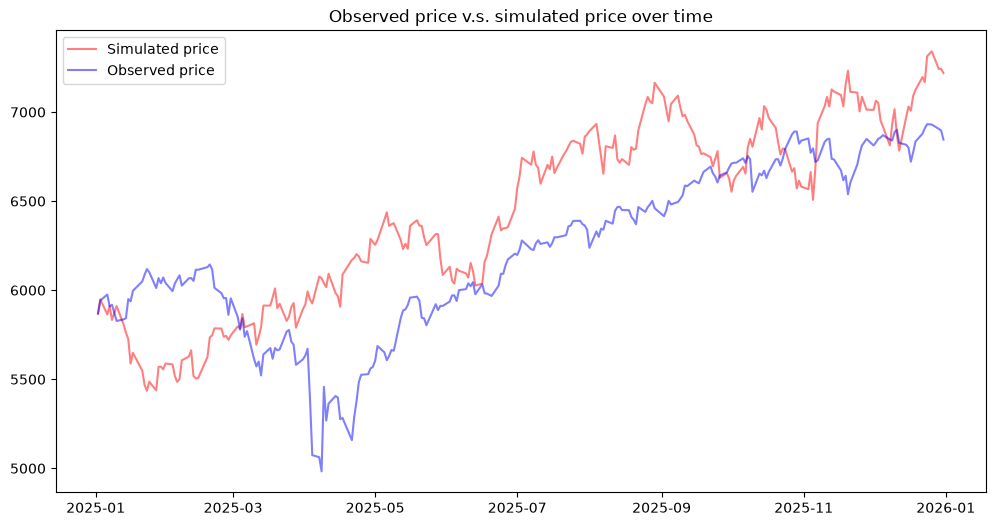

In [110]:
S0 = close[0][0]
n_prices = len(close)
n_returns = n_prices - 1
simulated_prices: List[float] = [S0]

rng = np.random.default_rng(seed=103)

daily_mu = annualized_mu / 252
daily_sigma = annualized_sigma / np.sqrt(252)

S_prev = S0;
for t in range(n_returns):
    St = S_prev * np.exp((daily_mu - 1/2 * daily_sigma**2) + daily_sigma * rng.normal())
    S_prev = St
    simulated_prices.append(St)

print(f"Simulated prices of size {len(simulated_prices)}: {simulated_prices}")

fig, ax = plt.subplots(figsize=(12,6))

ax.plot(price_days, simulated_prices, alpha=0.5, color='r', label='Simulated price')
ax.plot(price_days, close, alpha=0.5, color='b', label='Observed price')

ax.set_title("Observed price v.s. simulated price over time")
ax.legend()

plt.show()

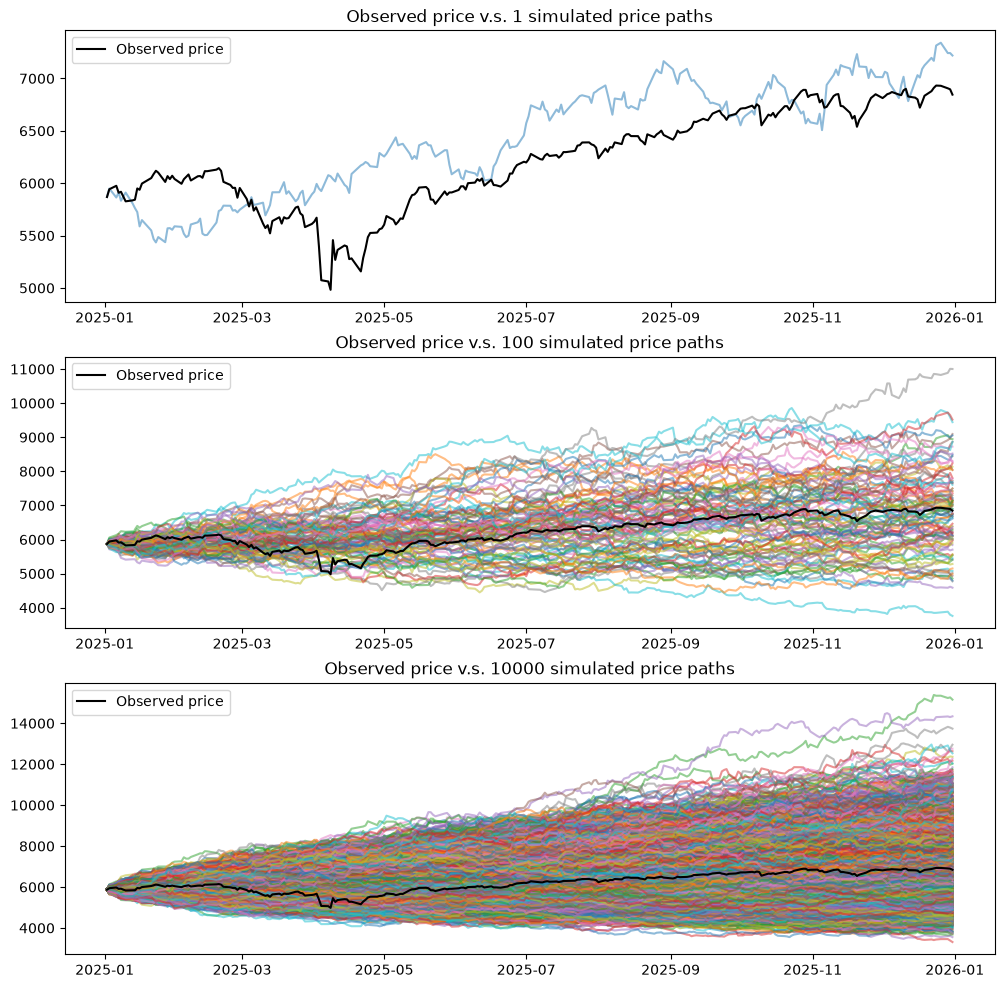

In [111]:
simulations = [1, 100, 10000]
dt = np.ones(shape=(n_returns,))
t = np.cumsum(dt)

simulated_prices: Dict[int, np.ndarray] = {}

for simulation in simulations:
    rng = np.random.default_rng(seed=103)

    dW = rng.normal(size=(simulation, n_returns))
    Wt = np.cumsum(dW, axis=1)
    St = S0 * np.exp((daily_mu - 1/2 * daily_sigma**2) * t + daily_sigma * Wt)

    S0_array = np.full(shape=(simulation,), fill_value=S0)
    St = np.vstack((S0_array, St.transpose()))

    simulated_prices[simulation] = St

fig, axes = plt.subplots(figsize=(12, 12), nrows=3)
for ax, simulation in zip(axes, simulations):
    ax.plot(price_days, simulated_prices[simulation], alpha=0.5)
    ax.plot(price_days, close, label='Observed price', color='k')
    ax.set_title(f"Observed price v.s. {simulation} simulated price paths")
    ax.legend()

plt.show();

## Plot terminal-price distribution

$S_T = S_0 e^{(\mu - \frac{1}{2} \sigma^2) T + \sigma W_T}$

$W_T \sim \mathcal{N}(0,T) => S_T$ is log-normally distributed under GBM

Thus, the distribution of terminal prices under GBM is right-skewed


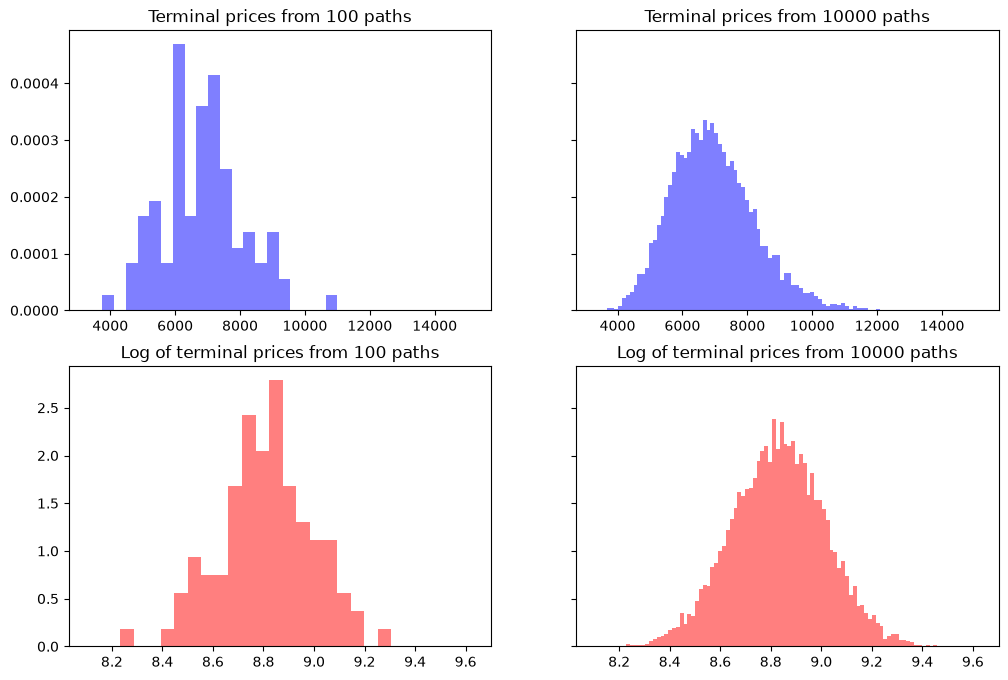

In [112]:
terminal_prices = {100: simulated_prices[100][-1,:], 10000: simulated_prices[10000][-1,:]}
log_of_terminal_prices = {100: np.log(terminal_prices[100]), 10000: np.log(terminal_prices[10000])}

fig, ax = plt.subplots(figsize=(12, 8), nrows=2, ncols=2, sharey='row', sharex='row')

ax[0][0].hist(terminal_prices[100], color='b', alpha=0.5, density=True, bins=20)
ax[0][0].set_title("Terminal prices from 100 paths")

ax[0][1].hist(terminal_prices[10000], color='b', alpha=0.5, density=True, bins=100)
ax[0][1].set_title("Terminal prices from 10000 paths")

ax[1][0].hist(log_of_terminal_prices[100], color='r', alpha=0.5, density=True, bins=20)
ax[1][0].set_title("Log of terminal prices from 100 paths")

ax[1][1].hist(log_of_terminal_prices[10000], color='r', alpha=0.5, density=True, bins=100)
ax[1][1].set_title("Log of terminal prices from 10000 paths")

plt.show();

## Estimate parameters from simulated data

1. Chi-square distribution: 

* Chi-square RV with $n$ ddof $\chi^2_n \coloneqq \sum_{i=1}^n Z_i^2$ where $Z_i \overset{\text{iid}}{\sim} \mathcal{N}(0,1)$

* $E[\chi^2_n] = \sum_{i=1}^n E[Z_i^2] = \sum_{i=1}^n (Var(Z_i) + (E[Z_i])^2) = \sum_{i=1}^n (1 + 0^2) = n$

* $Var(\chi^2_n) = \sum_{i=1}^n Var(Z_i^2) = \sum_{i=1}^n (E[Z_i^4] - (E[Z_i^2])^2) = \sum_{i=1}^n (3 - 1^2) = 2 n$

2. Scaled sample variance of $X$, where $X \overset{\text{iid}}{\sim} \mathcal{N}(\theta, \tau^2)$, follows a Chi-square distribution:

$\frac{(n-1) \hat{\tau}^2}{\tau^2} = \sum_{i=1}^n (\frac{X_i - \bar{X}}{\tau})^2 \sim \chi^2_{n-1} => 2(n-1) = Var(\frac{(n-1) \hat{\tau}^2}{\tau^2}) = \frac{(n-1)^2}{\tau^4} Var(\hat{\tau}^2) => Var(\hat{\tau}^2) = \frac{2\tau^4}{n-1}$

3. Delta method: If a sequence of random variables $X_n$ satisfying $\sqrt{n}(X_n - \theta) \overset{\text{d}}{\rightarrow} \mathcal{N}(0, \tau^2)$ where $\theta$ and $\tau$ are finite constants, then $\sqrt{n}(g(X_n) - g(\theta)) \overset{\text{d}}{\rightarrow} \mathcal{N}(0, [g'(\theta)]^2 \tau^2)$ for any function $g$ whose first derivative exists and is non-zero

3. Convergence rate of $\mu$ and $\sigma$:

Let $\hat{\theta}$ and $\hat{\tau}$ be the sample average and standard deviation of $r_t \overset{\text{iid}}{\sim} \mathcal{N}(\theta, \tau^2)$ where $\theta = (\mu - \frac{1}{2} \sigma^2)\Delta t$ and $\tau^2 = \sigma^2 \Delta t$

Given $\hat{\tau}^2 \approx \mathcal{N}(\tau^2, \frac{2\tau^4}{n-1})$, $\sqrt{n} (\hat{\tau}^2 - \tau^2) \overset{d}{\rightarrow} \mathcal{N}(0, 2\tau^4)$

Let $g(x) = \sqrt{x} => g'(x) = \frac{1}{2 \sqrt{x}}$

By applying the Delta method, $Var(\sqrt{n} (g(\hat{\tau}^2) - g(\tau^2))) = [g'(\tau^2)]^2 2\tau^4 => n Var(\hat{\tau}) = \frac{1}{4 \tau^2} 2\tau^4 => Var(\hat{\tau}) = \frac{\tau^2}{2n}$

$\hat{\sigma} = \frac{\hat{\tau}}{\sqrt{\Delta t}} => Var(\hat{\sigma}) = \frac{1}{\Delta t} \frac{\tau^2}{2n} = \frac{1}{\Delta t} \frac{\sigma^2 \Delta t}{2n} = \frac{\sigma^2}{2n} => SE(\hat{\sigma}) = \frac{\sigma}{\sqrt{2n}}$

$\hat{\mu} = \frac{\hat{\theta}}{\Delta t} + \frac{1}{2} \hat{\sigma}^2 = \frac{\hat{\theta}}{\Delta t} + \frac{\hat{\tau}^2}{2 \Delta t}$ where $\hat{\theta}$ and $\hat{\tau}^2$ are independent

$=> Var(\hat{\mu}) = \frac{1}{(\Delta t)^2} Var(\hat{\theta}) + \frac{1}{4 (\Delta t)^2} Var(\hat{\tau}^2) = \frac{1}{(\Delta t)^2} \frac{\tau^2}{n} + \frac{1}{4 (\Delta t)^2} \frac{2\tau^4}{n-1} = \frac{1}{(\Delta t)^2} \frac{\sigma^2 \Delta t}{n} + \frac{1}{4 (\Delta t)^2} \frac{2 \sigma^4 (\Delta t)^2}{n-1} = \frac{\sigma^2}{T} + \frac{\sigma^4}{2(n-1)}$

$=> SE(\hat{\mu}) = \sqrt{\frac{\sigma^2}{T} + \frac{\sigma^4}{2(n-1)}}$

Thus, under GBM, increasing sampling frequency over a fixed time horizon $T$ makes the volatility estimator increasingly precise given $SE(\hat{\sigma}) \rightarrow 0$ as $n \rightarrow \infty$. However, since $SE(\hat{\mu}) \rightarrow \sqrt{\frac{\sigma^2}{T}}$ as $n \rightarrow \infty$, improving drift estimation fundamentally requires longer observation horizon, rather than merely higher sampling frequency

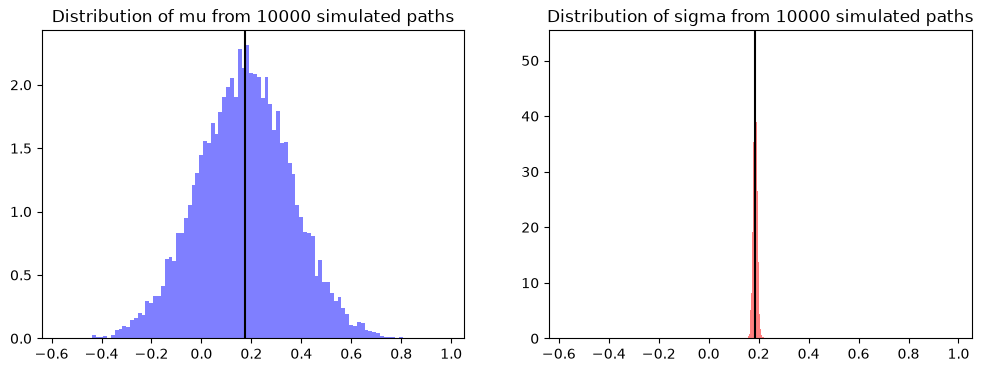

In [ ]:
# Estimate parameters for 10000 simulated price paths
mus = []
sigmas = []

for sim in range(10000):
    prices = simulated_prices[10000][:,sim]
    lagged_prices = prices[:-lag]
    prices = prices[lag:]

    log_returns = np.log(prices / lagged_prices)

    mean, std, mu, sigma = calculate_parameters(log_returns)

    mus.append(mu)
    sigmas.append(sigma)

fig, ax = plt.subplots(figsize=(12,4), ncols=2, sharex=True)

ax[0].hist(mus, bins=100, color='b', alpha=0.5, density=True)
ax[0].set_title("Distribution of mu from 10000 simulated paths")
ax[0].axvline(annualized_mu, color='k')

ax[1].hist(sigmas, bins=100, color='r', alpha=0.5, density=True)
ax[1].set_title("Distribution of sigma from 10000 simulated paths")
ax[1].axvline(annualized_sigma, color='k')

plt.show()

For 1-year sample:
Theoretical value: SE(mu) = 18.72%, SE(sigma) = 0.83%
Empirical value: SE(mu) = 18.74%, SE(sigma) = 0.83%

For 5-year sample:
Theoretical value: SE(mu) = 8.36%, SE(sigma) = 0.37%
Empirical value: SE(mu) = 8.27%, SE(sigma) = 0.37%

For 10-year sample:
Theoretical value: SE(mu) = 5.91%, SE(sigma) = 0.26%
Empirical value: SE(mu) = 5.92%, SE(sigma) = 0.26%



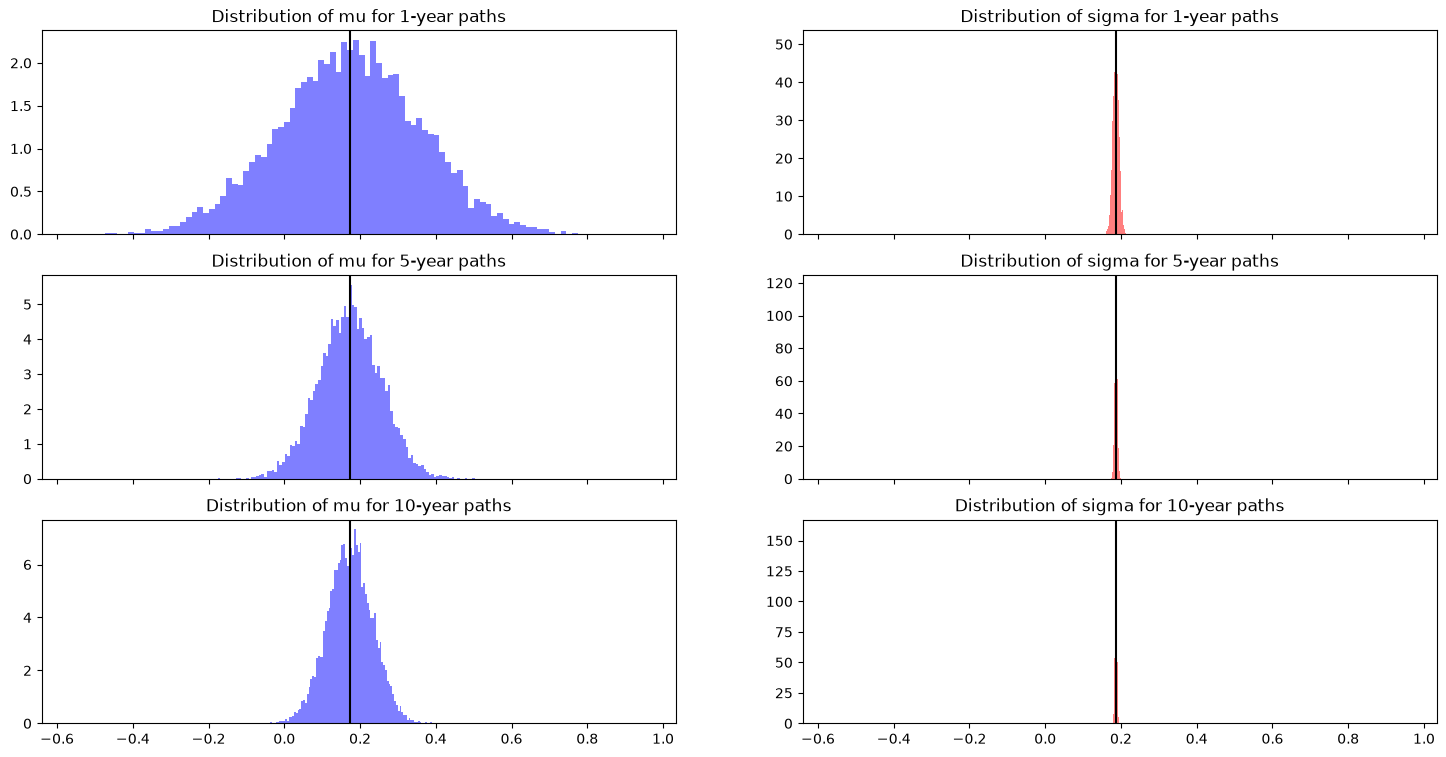

In [ ]:
# Generate 10000 paths and estimate parameters for each path length (1 year, 5 years, and 10 years)
years = [1,5,10]
simulated_prices: Dict[int, np.ndarray] = {}
mus: Dict[int, List[float]] = defaultdict(list)
sigmas: Dict[int, List[float]] = defaultdict(list)

for year in years:

    # Generate simulated prices
    n_prices = year * 252
    n_returns = n_prices - 1

    dt = np.ones(shape=(n_returns,))
    t = np.cumsum(dt)

    rng = np.random.default_rng(seed=103)

    dW = rng.normal(size=(10000, n_returns))
    Wt = np.cumsum(dW, axis=1)
    St = S0 * np.exp((daily_mu - 1/2 * daily_sigma**2) * t + daily_sigma * Wt)

    S0_array = np.full(shape=(10000,), fill_value=S0)
    St = np.vstack((S0_array, St.transpose()))

    simulated_prices[year] = St

    # Calculate parameters
    for sim in range(10000):
        prices = simulated_prices[year][:,sim]
        lagged_prices = prices[:-lag]
        prices = prices[lag:]

        log_returns = np.log(prices / lagged_prices)

        mean, std, mu, sigma = calculate_parameters(log_returns)

        mus[year].append(mu)
        sigmas[year].append(sigma)

    # Calculate theoretical and empirical SE of mu and sigma
    T = n_returns
    theoretical_se_mu = 252 * np.sqrt(daily_sigma**2 / T + daily_sigma**4 / (2 * (n_returns-1)))
    theoretical_se_sigma = np.sqrt(252) * daily_sigma / np.sqrt(2 * n_returns)

    empirical_se_mu = np.std(mus[year], ddof=1)
    empirical_se_sigma = np.std(sigmas[year], ddof=1)

    print(f"For {year}-year sample:")
    print(f"Theoretical value: SE(mu) = {theoretical_se_mu*100:.2f}%, SE(sigma) = {theoretical_se_sigma*100:.2f}%")
    print(f"Empirical value: SE(mu) = {empirical_se_mu*100:.2f}%, SE(sigma) = {empirical_se_sigma*100:.2f}%")
    print()

map = {
    (0,0): (1, mus[1]), (1,0): (5, mus[5]), (2,0): (10, mus[10]),
    (0,1): (1, sigmas[1]), (1,1): (5, sigmas[5]), (2,1): (10,sigmas[10])
    }

fig, ax = plt.subplots(figsize=(18,9), nrows=3, ncols=2, sharex=True)

for x, y in map.keys():
    year, estimators = map[(x,y)]

    if y == 0:
        color = 'b'
        vline = annualized_mu
        param = "mu"
    elif y == 1:
        color = 'r'
        vline = annualized_sigma
        param = "sigma"

    ax[x][y].hist(estimators, bins=100, color=color, alpha=0.5, density=True)
    ax[x][y].axvline(vline, color='k')
    ax[x][y].set_title(f"Distribution of {param} for {year}-year paths")

plt.show()